# TurboQuant on Kubernetes

Embed an art-image dataset through a CLIP service running on minikube, then compress the resulting vectors with TurboQuant and measure the memory + recall trade-off.

## Prerequisites (run on the host before starting this notebook)

1. `minikube start && minikube addons enable metrics-server`
2. `./setup_cluster.sh` — builds embedder + ingester images, loads them into minikube, deploys the embedder.
3. In a separate terminal: `minikube mount "$(pwd)/data:/data"` (leave it running). Used for embedding output only — image data is fetched directly by the ingester pods.

## 1. Run the ingester job

In a host terminal:

```bash
kubectl apply -f k8s/ingester-job.yaml
```

Four parallel ingester pods download the dataset tar from Hugging Face into pod-local `/tmp`, then POST batches to the `embedder` service. The HPA scales embedder pods 1 → 5 under load. Watch it live with:

```bash
kubectl get pods -n turboquant -w
```

In [1]:
import time
from pathlib import Path

N_SHARDS = 4
emb_dir = Path('data/embeddings')
print('Waiting for ingester shards')
while True:
    shards = sorted(emb_dir.glob('shard_*.npy'))
    print(f'  {len(shards)}/{N_SHARDS} shards present', end='\r', flush=True)
    if len(shards) == N_SHARDS:
        print()
        break
    time.sleep(5)

Waiting for ingester shards
  4/4 shards present


## 2. Combine shards

In [3]:
import json
import numpy as np

shards = sorted(emb_dir.glob('shard_*.npy'))
shard_arrays, image_names = [], []
for shard in shards:
    shard_arrays.append(np.load(shard))
    with open(shard.with_suffix('.json')) as f:
        image_names.extend(json.load(f))
image_embeds = np.concatenate(shard_arrays, axis=0)
print(f'Combined: {image_embeds.shape} ({len(image_names)} images)')

Combined: (1000, 512) (1000 images)


## 3. TurboQuant compression — memory comparison

In [4]:
import torch
from services.compression.turboquant_adc import TurboQuantIndex

DIM = image_embeds.shape[1]
image_embeds_torch = torch.from_numpy(image_embeds)

tq3 = TurboQuantIndex(dim=DIM, bits=3); tq3.add(image_embeds_torch)
tq4 = TurboQuantIndex(dim=DIM, bits=4); tq4.add(image_embeds_torch)

fp32_mb = image_embeds.nbytes / 1024**2
print(f'{"Method":<22}{"Memory":>14}{"Ratio":>10}')
print('-' * 46)
print(f'{"FP32 exact":<22}{fp32_mb:>11.1f} MB{"1.0x":>10}')
for label, tq in [('TurboQuant 3-bit', tq3), ('TurboQuant 4-bit', tq4)]:
    mem = tq.memory_bytes()
    print(f'{label:<22}{mem["compressed_mb"]:>11.2f} MB{mem["compression_ratio"]:>9.1f}x')

Method                        Memory     Ratio
----------------------------------------------
FP32 exact                    2.0 MB      1.0x
TurboQuant 3-bit             0.19 MB     10.2x
TurboQuant 4-bit             0.25 MB      7.8x


## 4. Recall@10 vs FP32 (text-image retrieval)

Ground-truth top-K is computed with `numpy.argsort` over the inner-product scores (single matmul on 1000 × 512 vectors — faiss would be overkill at this scale).

In [5]:
import open_clip

QUERIES = [
    'a dark knight in heavy armor',
    'futuristic city skyline at night',
    'samurai warrior in battle',
    'magical forest with glowing mushrooms',
    'underwater scene with fish',
    'cozy cabin in the snow',
    'oil painting of a castle',
    'neon cyberpunk street scene',
]
model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.eval()

with torch.no_grad():
    text_embeds_list = []
    for q in QUERIES:
        text_emb = model.encode_text(tokenizer([q]))
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
        text_embeds_list.append(text_emb.float())
query_embeds = torch.cat(text_embeds_list, dim=0)
print(f'Queries: {query_embeds.shape}')

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Queries: torch.Size([8, 512])


In [6]:
K = 10
fp32_scores = query_embeds.numpy() @ image_embeds.T
gt_top_k = np.argsort(-fp32_scores, axis=1)[:, :K]

def recall(tq_top_k):
    return float(np.mean([
        len(set(gt_top_k[i].tolist()) & set(tq_top_k[i].tolist())) / K
        for i in range(len(QUERIES))
    ]))

print(f'{"Method":<28}{"Recall@" + str(K):>12}')
print('-' * 40)
for label, tq in [('TurboQuant 3-bit', tq3), ('TurboQuant 4-bit', tq4)]:
    _, tq_ids = tq.search(query_embeds, k=K)
    print(f'{label:<28}{recall(tq_ids.numpy()):>12.3f}')
    _, tq_ids = tq.search(query_embeds, k=K, rerank=True, rerank_mult=2, fp32_vectors=image_embeds)
    print(f'{label + " + rerank x2":<28}{recall(tq_ids.numpy()):>12.3f}')

Method                         Recall@10
----------------------------------------
TurboQuant 3-bit                   0.775
TurboQuant 3-bit + rerank x2       0.963
TurboQuant 4-bit                   0.900
TurboQuant 4-bit + rerank x2       1.000


## 5. Visualize the top results

See what's actually retrieved. The next cell pulls the image files locally so we can render them; the cell after plots a grid of the top-5 matches per query.

In [7]:
import os
import tarfile
import urllib.request

img_dir = Path('data/images')
img_dir.mkdir(parents=True, exist_ok=True)
needed = set(image_names)
present = set(p.name for p in img_dir.glob('*.jpg'))
if not needed.issubset(present):
    archive = '/tmp/images_vis.tar'
    urllib.request.urlretrieve(
        'https://huggingface.co/datasets/twood1/turboquant-art-1k/resolve/main/images_1k.tar',
        archive,
    )
    with tarfile.open(archive, 'r') as tf:
        tf.extractall(img_dir)
    os.remove(archive)
print(f'{sum(1 for _ in img_dir.glob("*.jpg"))} images in {img_dir}')

/tmp/ipykernel_21/1426216118.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(img_dir)


1000 images in data/images


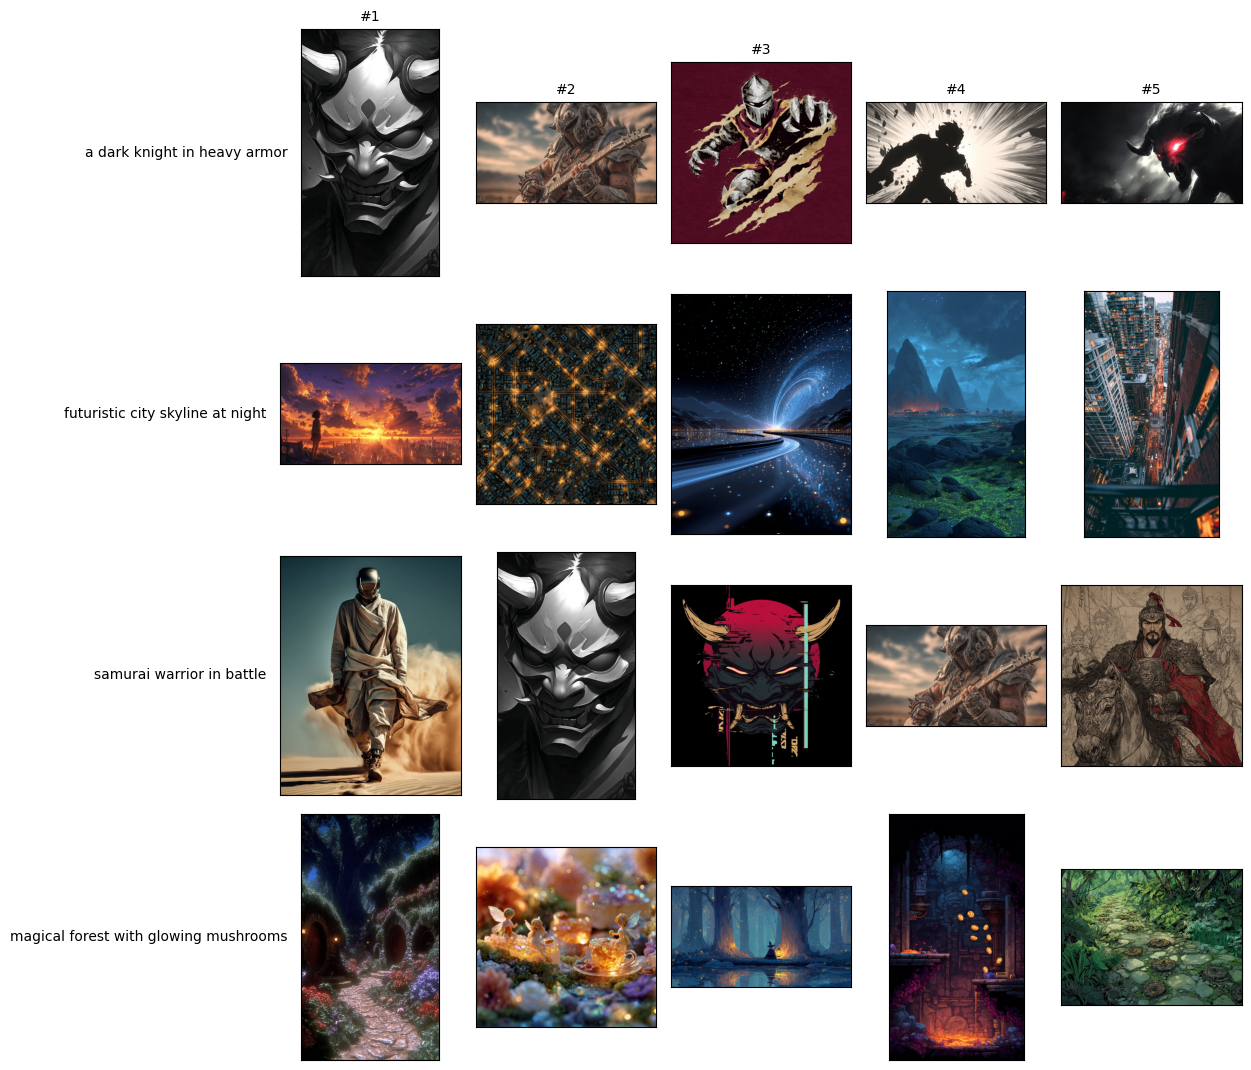

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

K_VIZ = 5
N_QUERIES = min(4, len(QUERIES))

top_idx = np.argsort(-fp32_scores, axis=1)[:, :K_VIZ]

fig, axes = plt.subplots(N_QUERIES, K_VIZ, figsize=(2.5 * K_VIZ, 2.7 * N_QUERIES))
for q_i in range(N_QUERIES):
    for k_i in range(K_VIZ):
        idx = top_idx[q_i, k_i]
        img = Image.open(img_dir / image_names[idx])
        ax = axes[q_i, k_i] if N_QUERIES > 1 else axes[k_i]
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        if k_i == 0:
            ax.set_ylabel(QUERIES[q_i], fontsize=10, rotation=0, ha='right', va='center', labelpad=10)
        if q_i == 0:
            ax.set_title(f'#{k_i + 1}', fontsize=10)
plt.tight_layout()
plt.show()